In [ ]:
import pickle
import pysam
import pyBigWig
from tqdm.auto import tqdm
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr
from sklearn.metrics import roc_auc_score
import seaborn as sns
import os
from datetime import datetime
from methylseqnet.builders import MultiBigWigLabelHandler
from methylseqnet_repro.paths import fiberseq_tracks
from methylseqnet.readers import load_total_counts

In [2]:
# for label in [
#     fiberseq_tracks / "UDN318336_trackHub/bw/hap1.acc.bw",
#     fiberseq_tracks / "UDN318336_trackHub/bw/hap2.acc.bw",
#     fiberseq_tracks / "UDN318336_retinal_trackHub/bw/hap1.acc.bw",
#     fiberseq_tracks / "UDN318336_retinal_trackHub/bw/hap2.acc.bw",
#     fiberseq_tracks / "GM12878_trackHub/bw/hap1.acc.bw",
#     fiberseq_tracks / "GM12878_trackHub/bw/hap2.acc.bw",
# ]:
#     print(label.parent.parent.name, load_total_counts(label))

factorized true methylation chrX 2026-03-22 15:49:29.850633
(275,) (275,) (275,) (275,) (275,) (275,)
134 out of 275 pass RNA-seq mask
factorized true methylation chr13 2026-03-23 08:13:47.656900


/tmp/ipykernel_3137222/3513064649.py:130: RuntimeWarning: invalid value encountered in divide
  hp1_corrected_cts = (hp1_rna_cts_array * rna_cts_array / (hp1_rna_cts_array + hp2_rna_cts_array + pseudocount/128))[rna_cts_mask] + 0.01/128
/tmp/ipykernel_3137222/3513064649.py:131: RuntimeWarning: invalid value encountered in divide
  hp2_corrected_cts = (hp2_rna_cts_array * rna_cts_array / (hp1_rna_cts_array + hp2_rna_cts_array + pseudocount/128))[rna_cts_mask] + 0.01/128


(849,) (849,) (849,) (849,) (849,) (849,)
478 out of 849 pass RNA-seq mask
factorized true methylation imprinted 2026-03-23 08:14:42.823235
(19,) (19,) (19,) (19,) (19,) (19,)
13 out of 19 pass RNA-seq mask
factorized imputed methylation chrX 2026-03-23 08:26:48.696308
(275,) (275,) (275,) (275,) (275,) (275,)
134 out of 275 pass RNA-seq mask
factorized imputed methylation chr13 2026-03-23 08:53:58.650175
(849,) (849,) (849,) (849,) (849,) (849,)
478 out of 849 pass RNA-seq mask
factorized imputed methylation imprinted 2026-03-23 08:54:53.046050
(19,) (19,) (19,) (19,) (19,) (19,)
13 out of 19 pass RNA-seq mask


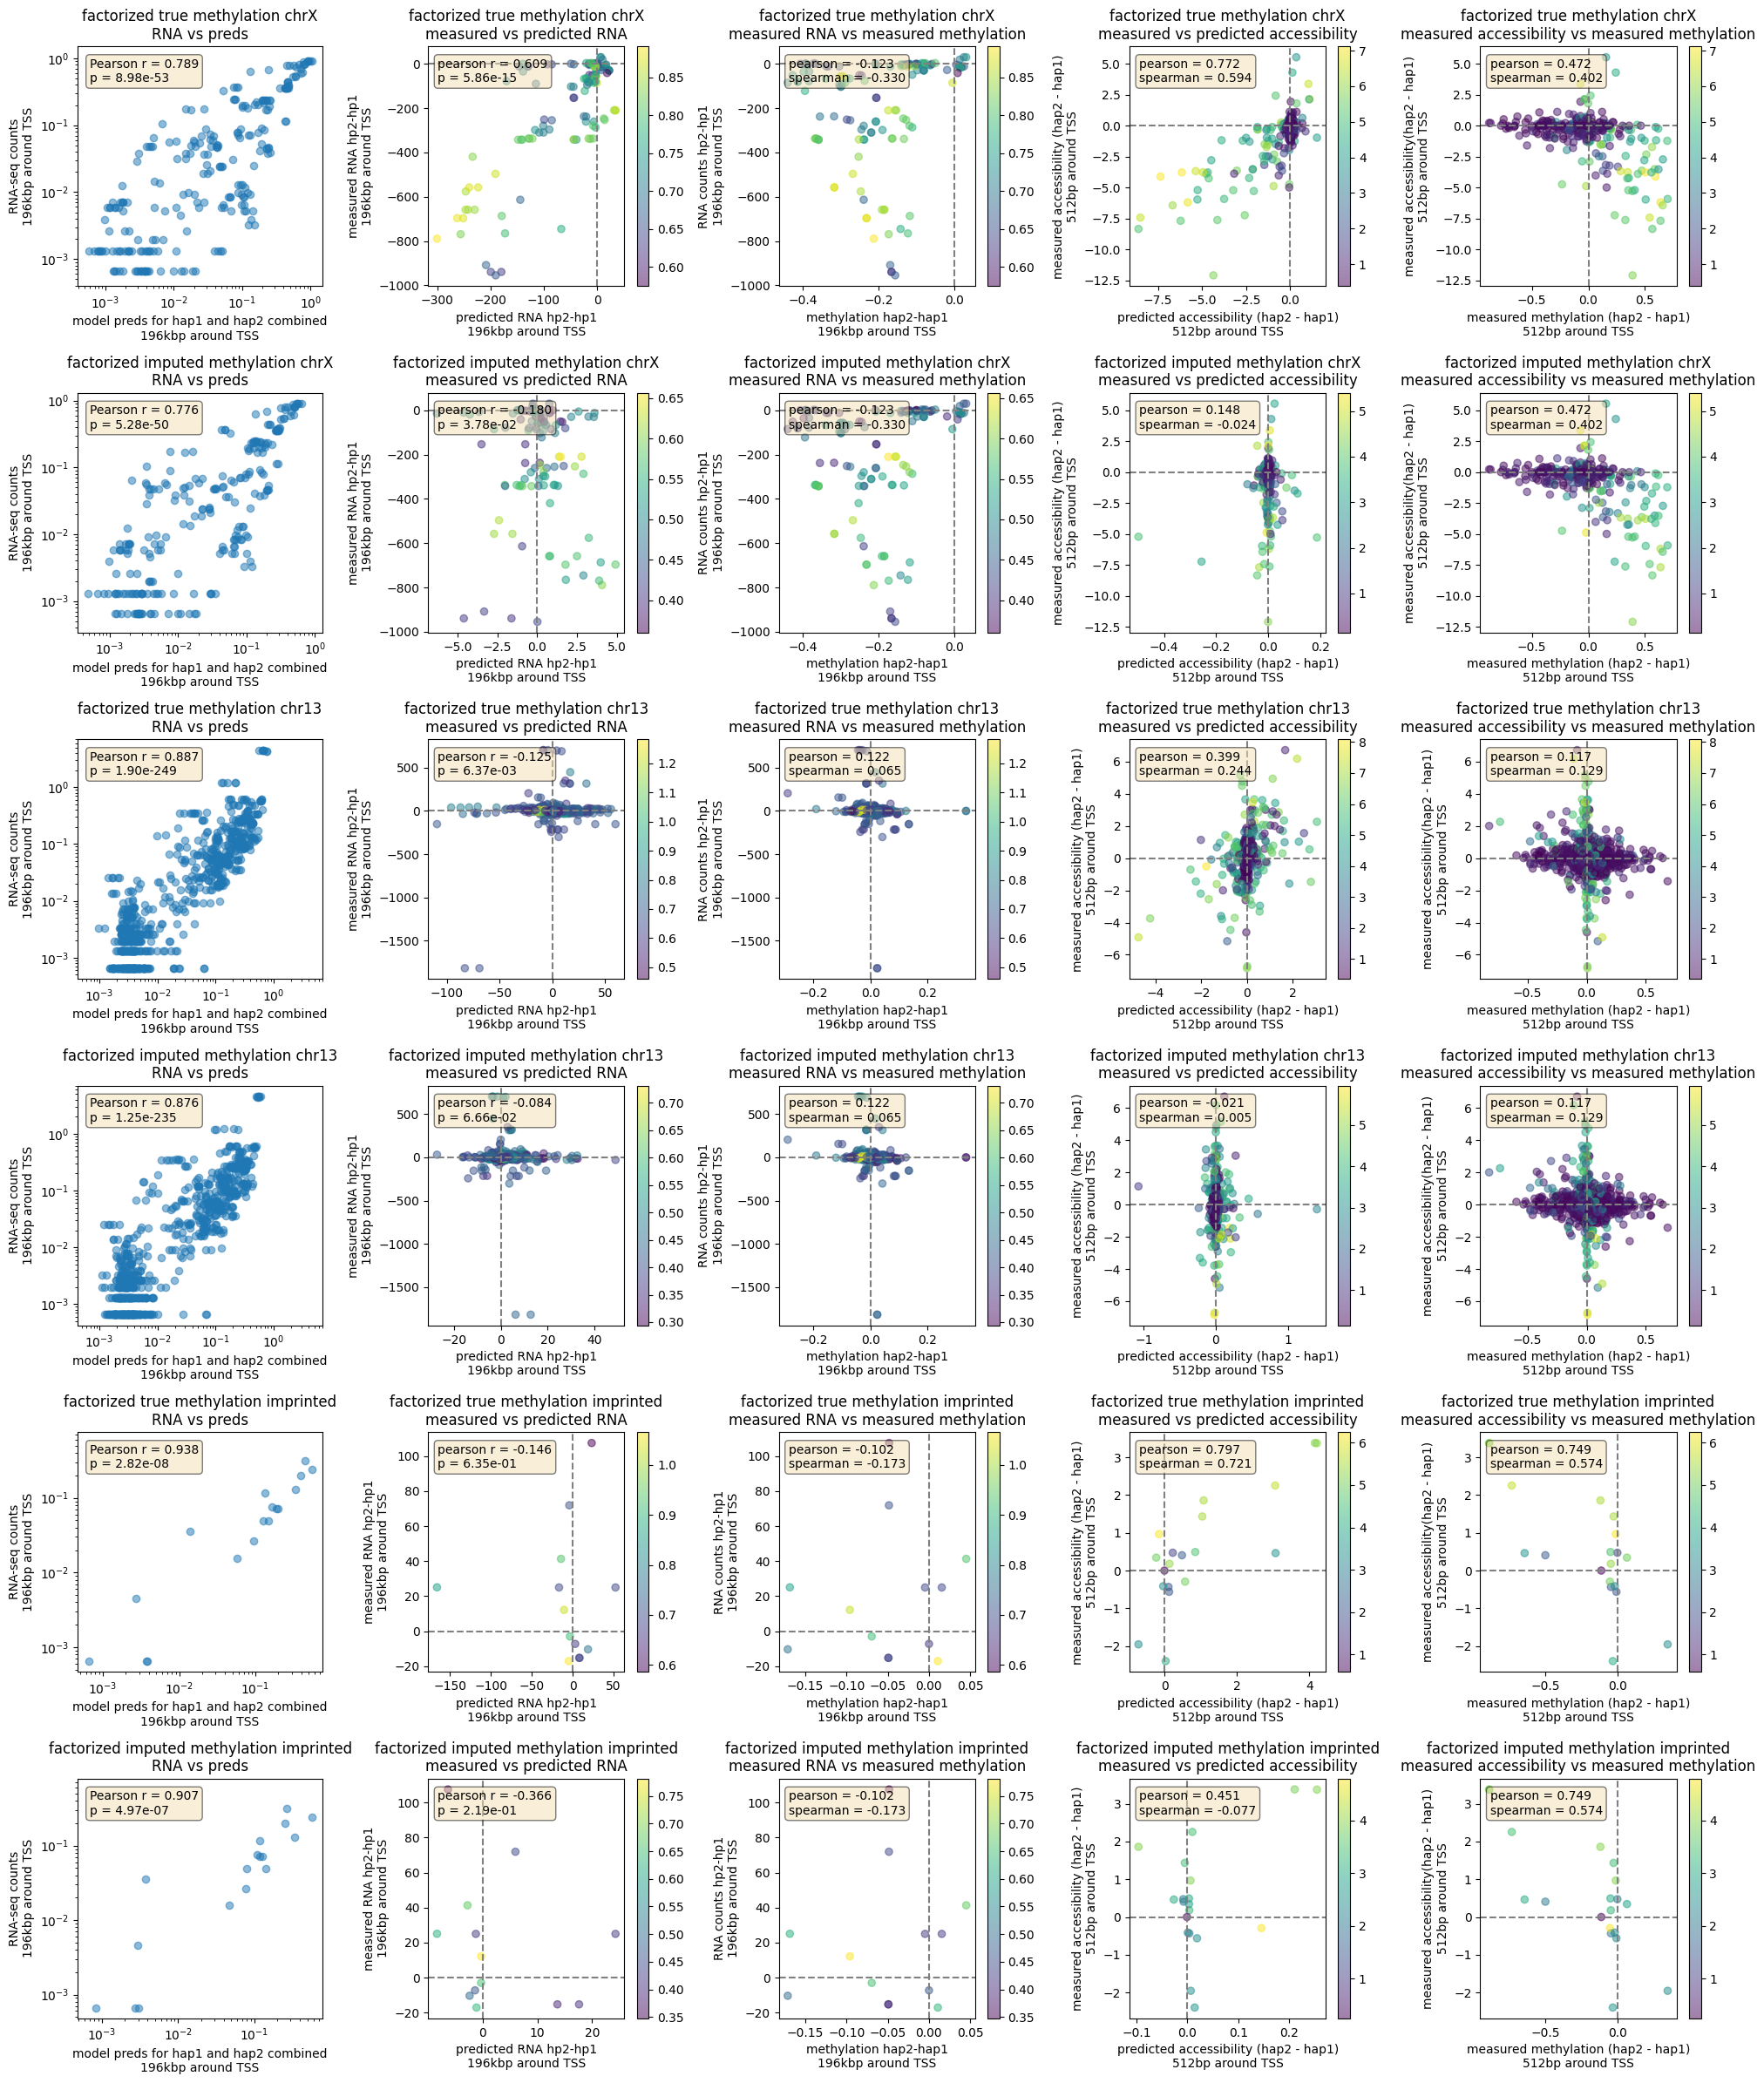

In [3]:
pseudocount = 0.0
def sign_concordance(predictions, truth):
    """
    Calculate the fraction of observations where predictions 
    and truth have the same sign.
    
    Returns: fraction between 0 and 1
    """
    same_sign = np.sign(predictions) == np.sign(truth)
    return np.mean(same_sign)

def square_lims(ax):
    lims = [min(*ax.get_xlim(), *ax.get_ylim()),
            max(*ax.get_xlim(), *ax.get_ylim())]
    ax.set_xlim(lims)
    ax.set_ylim(lims)

def add_y_equals_x(ax, *args, **kwargs):
    lims = [min(*ax.get_xlim(), *ax.get_ylim()),
            max(*ax.get_xlim(), *ax.get_ylim())]
    ax.plot(lims, lims, *args, **kwargs)

folds = "test"

accessibility_capture_window = 2
rna_capture_window = 768

for channels_selection in ['rna-fiber']:
        processed_checkpoints_dict = {
            "factorized true methylation": {
                "chrX": f"pickles/checkpoint_slurm32260895task0_{folds}_chrX_capture{accessibility_capture_window},{rna_capture_window}_{channels_selection}_snp_sequence.pkl",
                "chr13": f"pickles/checkpoint_slurm32260895task0_{folds}_chr13_capture{accessibility_capture_window},{rna_capture_window}_{channels_selection}_snp_sequence.pkl",
                "imprinted": f"pickles/checkpoint_slurm32260895task0_{folds}_imprinted_capture{accessibility_capture_window},{rna_capture_window}_{channels_selection}_snp_sequence.pkl",
            },
            "factorized imputed methylation": {
                "chrX": f"pickles/checkpoint_slurm32260895task1_{folds}_chrX_capture{accessibility_capture_window},{rna_capture_window}_{channels_selection}_snp_sequence.pkl",
                "chr13": f"pickles/checkpoint_slurm32260895task1_{folds}_chr13_capture{accessibility_capture_window},{rna_capture_window}_{channels_selection}_snp_sequence.pkl",
                "imprinted": f"pickles/checkpoint_slurm32260895task1_{folds}_imprinted_capture{accessibility_capture_window},{rna_capture_window}_{channels_selection}_snp_sequence.pkl",
            },
        }
        num_models = len(processed_checkpoints_dict)
        num_chroms = max(len(v) for v in processed_checkpoints_dict.values())
        num_plots_per_condition = 5
        fig, axs = plt.subplots(num_models*num_chroms, num_plots_per_condition, figsize=(num_plots_per_condition*4, 4*num_models*num_chroms))
        # fig.suptitle(f"Model predictions vs CAGE/RNA-seq ({channels_selection} channels)", fontsize=16)

        for model_idx, (model_description, chroms_dict) in enumerate(processed_checkpoints_dict.items()):
            for chrom_idx, (chrom, processed_data_checkpoint) in enumerate(chroms_dict.items()):
                description = f"{model_description} {chrom}"
                print(description, datetime.fromtimestamp(os.path.getmtime(processed_data_checkpoint)))
                checkpoint = pickle.load(open(processed_data_checkpoint, 'rb'))

                cage_array = np.array(checkpoint['cage_cts_list'])
                hp1_preds_array = np.array(checkpoint['hp1_preds'])
                hp2_preds_array = np.array(checkpoint['hp2_preds'])
                rna_cts_array = np.array(checkpoint['rna_cts_list'])
                hp1_rna_cts_array = np.array(checkpoint['rna_cts_list_hp1'])
                hp2_rna_cts_array = np.array(checkpoint['rna_cts_list_hp2'])
                hp1_acc_targets = np.array(checkpoint.get('hp1_acc_targets', []))
                hp2_acc_targets = np.array(checkpoint.get('hp2_acc_targets', []))
                hp1_acc_preds = np.array(checkpoint.get('hp1_acc_preds', []))
                hp2_acc_preds = np.array(checkpoint.get('hp2_acc_preds', []))
                hp1_methylations = np.array(checkpoint.get('hp1_methylations', []))
                hp2_methylations = np.array(checkpoint.get('hp2_methylations', []))
                hp1_rna_methylations = np.array(checkpoint.get('hp1_rna_methylations', []))
                hp2_rna_methylations = np.array(checkpoint.get('hp2_rna_methylations', []))
                hp1_acc_conditional_seq_reps = np.array(checkpoint.get('hp1_acc_conditional_seq_reps', []))
                hp2_acc_conditional_seq_reps = np.array(checkpoint.get('hp2_acc_conditional_seq_reps', []))
                hp1_rna_conditional_seq_reps = np.array(checkpoint.get('hp1_rna_conditional_seq_reps', []))
                hp2_rna_conditional_seq_reps = np.array(checkpoint.get('hp2_rna_conditional_seq_reps', []))
                hp1_acc_unconditional_seq_reps = np.array(checkpoint.get('hp1_acc_unconditional_seq_reps', []))
                hp2_acc_unconditional_seq_reps = np.array(checkpoint.get('hp2_acc_unconditional_seq_reps', []))
                hp1_rna_unconditional_seq_reps = np.array(checkpoint.get('hp1_rna_unconditional_seq_reps', []))
                hp2_rna_unconditional_seq_reps = np.array(checkpoint.get('hp2_rna_unconditional_seq_reps', []))

                # print(
                #     "cage", cage_array,
                #     "hp1_preds", hp1_preds_array,
                #     "hp2_preds", hp2_preds_array,
                #     "rna", rna_cts_array,
                #     "hp1_rna", hp1_rna_cts_array,
                #     "hp2_rna", hp2_rna_cts_array,
                #     "hp1_acc_targets", hp1_acc_targets,
                #     "hp2_acc_targets", hp2_acc_targets,
                #     "hp1_acc_preds", hp1_acc_preds,
                #     "hp2_acc_preds", hp2_acc_preds,
                #     "hp1_methylations", hp1_methylations,
                #     "hp2_methylations", hp2_methylations,
                # )

                if len(hp1_preds_array) == 0 or len(hp2_preds_array) == 0 or not np.any(hp1_preds_array>0) or not np.any(hp2_preds_array>0):
                    print("No predictions found, skipping...")
                    continue

                print(cage_array.shape, hp1_preds_array.shape, hp2_preds_array.shape, rna_cts_array.shape, hp1_rna_cts_array.shape, hp2_rna_cts_array.shape)

                rna_cts_mask = (hp1_rna_cts_array + hp2_rna_cts_array + pseudocount > 0) & (hp1_rna_cts_array + pseudocount > 0) & (hp2_rna_cts_array + pseudocount > 0)
                #((hp1_rna_cts_array + hp2_rna_cts_array) > .01) & ((hp1_rna_cts_array + hp2_rna_cts_array)/rna_cts_array > 0.01)
                print(sum(rna_cts_mask), "out of", len(rna_cts_mask), "pass RNA-seq mask")

                rna_cts_to_plot = rna_cts_array
                axs[chrom_idx*num_models + model_idx,0].scatter(
                    y=128*(rna_cts_to_plot + pseudocount),
                    x=(hp1_preds_array + 
                    hp2_preds_array + pseudocount)/2,
                    alpha=0.5,
                )
                axs[chrom_idx*num_models + model_idx,0].loglog()
                axs[chrom_idx*num_models + model_idx,0].set_title(f"{description}\nRNA vs preds")
                rna_mask = (rna_cts_to_plot > 0) & (hp1_preds_array + hp2_preds_array > 0)
                pearson_r_rna, pearson_p_rna = pearsonr(
                    np.log10((rna_cts_to_plot)[rna_mask] + pseudocount),
                    np.log10((hp1_preds_array + hp2_preds_array)[rna_mask] + pseudocount)
                )
                axs[chrom_idx*num_models + model_idx,0].text(
                    0.05, 0.95,
                    f'Pearson r = {pearson_r_rna:.3f}\np = {pearson_p_rna:.2e}',
                    transform=axs[chrom_idx*num_models + model_idx,0].transAxes,
                    verticalalignment='top',
                    bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5)
                )
                axs[chrom_idx*num_models + model_idx,0].set_xlabel(f"model preds for hap1 and hap2 combined\n{rna_capture_window*2*128//1000}kbp around TSS")
                axs[chrom_idx*num_models + model_idx,0].set_ylabel(f"RNA-seq counts\n{rna_capture_window*2*128//1000}kbp around TSS")
                square_lims(axs[chrom_idx*num_models + model_idx,0])


                rna_differential_meas = ((hp1_rna_cts_array[rna_cts_mask]/(hp1_rna_cts_array[rna_cts_mask]+hp2_rna_cts_array[rna_cts_mask])))+0.01
                rna_differential_pred = ((hp1_preds_array[rna_cts_mask]/(hp1_preds_array[rna_cts_mask]+hp2_preds_array[rna_cts_mask])))+0.01
                
                hp1_corrected_cts = (hp1_rna_cts_array * rna_cts_array / (hp1_rna_cts_array + hp2_rna_cts_array + pseudocount/128))[rna_cts_mask] + 0.01/128
                hp2_corrected_cts = (hp2_rna_cts_array * rna_cts_array / (hp1_rna_cts_array + hp2_rna_cts_array + pseudocount/128))[rna_cts_mask] + 0.01/128


                rna_cts_to_plot = hp1_rna_cts_array + hp2_rna_cts_array            
                # lfc_rna = np.log2((hp1_corrected_cts + pseudocount) / (hp2_corrected_cts + pseudocount))
                # lfc_pred = np.log2((hp2_preds_array[rna_cts_mask] + pseudocount) / (hp1_preds_array[rna_cts_mask] + pseudocount))
                # lfc_rna = hp1_corrected_cts - hp2_corrected_cts
                # lfc_pred = hp2_preds_array[rna_cts_mask] - hp1_preds_array[rna_cts_mask]
                # lfc_rna = np.log2(128*hp1_corrected_cts+1) - np.log2(128*hp2_corrected_cts+1)
                # lfc_pred = np.log2(hp1_preds_array[rna_cts_mask]+1) - np.log2(hp2_preds_array[rna_cts_mask]+1)

                lfc_rna = 1536*(128*hp2_corrected_cts - 128*hp1_corrected_cts)
                lfc_pred = 1536*(hp2_preds_array[rna_cts_mask] - hp1_preds_array[rna_cts_mask])

                pearson_r_lfc, pearson_p_lfc = spearmanr(lfc_rna, lfc_pred)
                sc = axs[chrom_idx*num_models + model_idx,1].scatter(
                    y=lfc_rna,
                    x=lfc_pred,
                    alpha=0.5,
                    c=(hp2_rna_conditional_seq_reps[rna_cts_mask] + hp1_rna_conditional_seq_reps[rna_cts_mask]), # - (hp2_rna_unconditional_seq_reps[rna_cts_mask] + hp1_rna_unconditional_seq_reps[rna_cts_mask]),
                    cmap='viridis',
                )
                plt.colorbar(sc)
                axs[chrom_idx*num_models + model_idx,1].axvline(0, color='gray', linestyle='--')
                axs[chrom_idx*num_models + model_idx,1].axhline(0, color='gray', linestyle='--')
                axs[chrom_idx*num_models + model_idx,1].set_title(f"{description}\nmeasured vs predicted RNA")

                axs[chrom_idx*num_models + model_idx,1].text(
                    0.05, 0.95,
                    f'pearson r = {pearson_r_lfc:.3f}\np = {pearson_p_lfc:.2e}',
                    transform=axs[chrom_idx*num_models + model_idx,1].transAxes,
                    verticalalignment='top',
                    bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5)
                )
                axs[chrom_idx*num_models + model_idx,1].set_xlabel(f"predicted RNA hp2-hp1\n{rna_capture_window*2*128//1000}kbp around TSS")
                axs[chrom_idx*num_models + model_idx,1].set_ylabel(f"measured RNA hp2-hp1\n{rna_capture_window*2*128//1000}kbp around TSS")

                acc_pred_differential = (hp2_acc_preds - hp1_acc_preds)
                acc_meas_differential = (hp2_acc_targets - hp1_acc_targets)
                methylations_differential = (hp2_methylations - hp1_methylations)
                r_pearson_acc, p_pearson_acc = pearsonr(acc_pred_differential, acc_meas_differential)
                r_spearman_acc, p_spearman_acc = spearmanr(acc_pred_differential, acc_meas_differential)
                r_pearson_methyl, p_pearson_methyl = pearsonr(-methylations_differential, acc_meas_differential)
                r_spearman_methyl, p_spearman_methyl = spearmanr(-methylations_differential, acc_meas_differential)
                data = np.concatenate([acc_pred_differential, acc_meas_differential])
                labels = ['pred']*len(acc_pred_differential) + ['meas']*len(acc_meas_differential)
                cond_reps = (hp2_acc_conditional_seq_reps + hp1_acc_conditional_seq_reps)
                sc = axs[chrom_idx*num_models + model_idx,3].scatter(
                    y=acc_meas_differential,
                    x=acc_pred_differential,
                    alpha=0.5,
                    c=cond_reps,  # np.log2(/ (hp2_acc_unconditional_seq_reps + hp1_acc_unconditional_seq_reps)), # - (hp2_acc_unconditional_seq_reps + hp1_acc_unconditional_seq_reps),
                    cmap='viridis',
                )
                plt.colorbar(sc, )
                axs[chrom_idx*num_models + model_idx,3].set_title(f"{description}\nmeasured vs predicted accessibility")
                axs[chrom_idx*num_models + model_idx,3].set_xlabel(f"predicted accessibility (hap2 - hap1)\n{accessibility_capture_window*2*128}bp around TSS")
                axs[chrom_idx*num_models + model_idx,3].set_ylabel(f"measured accessibility (hap2 - hap1)\n{accessibility_capture_window*2*128}bp around TSS")
                axs[chrom_idx*num_models + model_idx,3].text(
                    0.05, 0.95,
                    f'pearson = {r_pearson_acc:.3f}\nspearman = {r_spearman_acc:.3f}',
                    transform=axs[chrom_idx*num_models + model_idx,3].transAxes,
                    verticalalignment='top',
                    bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5)
                )
                axs[chrom_idx*num_models + model_idx,3].axvline(0, color='gray', linestyle='--')
                axs[chrom_idx*num_models + model_idx,3].axhline(0, color='gray', linestyle='--')
                sc = axs[chrom_idx*num_models + model_idx,4].scatter(
                    y=acc_meas_differential,
                    x=methylations_differential,
                    alpha=0.5,
                    c=cond_reps, #np.log2( / (hp2_acc_unconditional_seq_reps + hp1_acc_unconditional_seq_reps)),
                    cmap='viridis',
                )
                plt.colorbar(sc)
                axs[chrom_idx*num_models + model_idx,4].set_title(f"{description}\nmeasured accessibility vs measured methylation")
                axs[chrom_idx*num_models + model_idx,4].set_xlabel(f"measured methylation (hap2 - hap1)\n{accessibility_capture_window*2*128}bp around TSS")
                axs[chrom_idx*num_models + model_idx,4].set_ylabel(f"measured accessibility(hap2 - hap1)\n{accessibility_capture_window*2*128}bp around TSS")
                axs[chrom_idx*num_models + model_idx,4].text(
                    0.05, 0.95,
                    f'pearson = {r_pearson_methyl:.3f}\nspearman = {r_spearman_methyl:.3f}',
                    transform=axs[chrom_idx*num_models + model_idx,4].transAxes,
                    verticalalignment='top',
                    bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5)
                )
                axs[chrom_idx*num_models + model_idx,4].axvline(0, color='gray', linestyle='--')
                axs[chrom_idx*num_models + model_idx,4].axhline(0, color='gray', linestyle='--')

                sc = axs[chrom_idx*num_models + model_idx,2].scatter(
                    y=lfc_rna,
                    x=hp2_rna_methylations[rna_cts_mask] - hp1_rna_methylations[rna_cts_mask],
                    alpha=0.5,
                    c=(hp2_rna_conditional_seq_reps[rna_cts_mask] + hp1_rna_conditional_seq_reps[rna_cts_mask]), # - (hp2_rna_unconditional_seq_reps[rna_cts_mask] + hp1_rna_unconditional_seq_reps[rna_cts_mask]),
                    cmap='viridis',
                )
                plt.colorbar(sc)
                r_pearson_rna_methyl, p_pearson_rna_methyl = pearsonr(-lfc_rna, hp2_rna_methylations[rna_cts_mask] - hp1_rna_methylations[rna_cts_mask])
                r_spearman_rna_methyl, p_spearman_rna_methyl = spearmanr(-lfc_rna, hp2_rna_methylations[rna_cts_mask] - hp1_rna_methylations[rna_cts_mask])
                axs[chrom_idx*num_models + model_idx,2].set_title(f"{description}\nmeasured RNA vs measured methylation")
                axs[chrom_idx*num_models + model_idx,2].set_xlabel(f"methylation hap2-hap1\n{rna_capture_window*2*128//1000}kbp around TSS")
                axs[chrom_idx*num_models + model_idx,2].set_ylabel(f"RNA counts hp2-hp1\n{rna_capture_window*2*128//1000}kbp around TSS")
                axs[chrom_idx*num_models + model_idx,2].text(
                    0.05, 0.95,
                    f'pearson = {r_pearson_rna_methyl:.3f}\nspearman = {r_spearman_rna_methyl:.3f}',
                    transform=axs[chrom_idx*num_models + model_idx,2].transAxes,
                    verticalalignment='top',
                    bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5)
                )
                axs[chrom_idx*num_models + model_idx,2].axvline(0, color='gray', linestyle='--')
                axs[chrom_idx*num_models + model_idx,2].axhline(0, color='gray', linestyle='--')
                # axs[chrom_idx*num_models + model_idx,5].scatter(
                #     acc_meas_differential,
                #     (hp2_acc_conditional_seq_reps + hp1_acc_conditional_seq_reps) - (hp2_acc_unconditional_seq_reps + hp1_acc_unconditional_seq_reps),
                #     alpha=0.1,
                # )
                # pearson_reps = pearsonr(
                #     acc_meas_differential,
                #     (hp2_acc_conditional_seq_reps + hp1_acc_conditional_seq_reps) - (hp2_acc_unconditional_seq_reps + hp1_acc_unconditional_seq_reps)
                # )
                # axs[chrom_idx*num_models + model_idx,5].set_title(f"{description}\nAcc. differential vs conditional/unconditional seq rep ratio")
                # axs[chrom_idx*num_models + model_idx,5].set_xlabel("measured acc. diff. (hap2 - hap1)")
                # axs[chrom_idx*num_models + model_idx,5].set_ylabel("cond/uncond seq rep ratio")
                # axs[chrom_idx*num_models + model_idx,5].text(
                #     0.05, 0.95,
                #     f'pearson r = {pearson_reps[0]:.3f}\np = {pearson_reps[1]:.2e}',
                #     transform=axs[chrom_idx*num_models + model_idx,5].transAxes,
                #     verticalalignment='top',
                #     bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5)
                # )


        fig.tight_layout()
        plt.show()

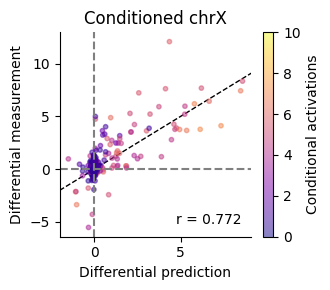

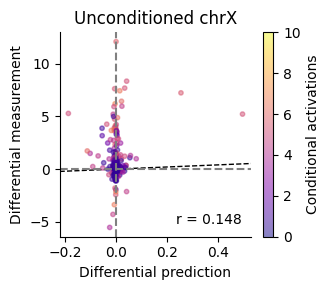

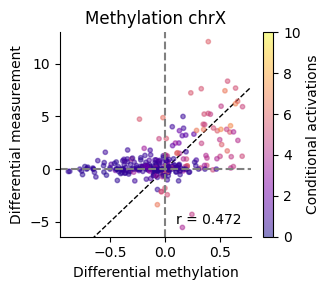

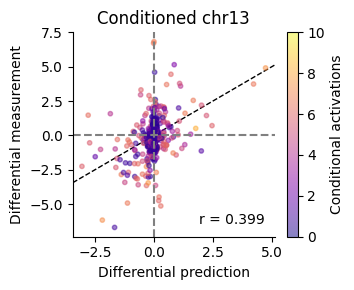

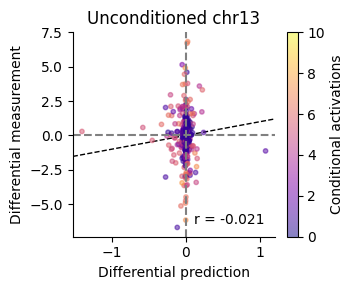

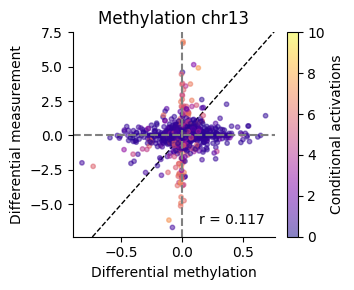

In [7]:
from scipy.stats import pearsonr

folds = "test"

accessibility_capture_window = 2
rna_capture_window = 768

true_meth_pickles = {
    "chrX": f"pickles/checkpoint_slurm32260895task0_{folds}_chrX_capture{accessibility_capture_window},{rna_capture_window}_rna-fiber_snp_sequence.pkl",
    "chr13": f"pickles/checkpoint_slurm32260895task0_{folds}_chr13_capture{accessibility_capture_window},{rna_capture_window}_rna-fiber_snp_sequence.pkl",
}
imputed_meth_pickles = {
    "chrX": f"pickles/checkpoint_slurm32260895task1_{folds}_chrX_capture{accessibility_capture_window},{rna_capture_window}_rna-fiber_snp_sequence.pkl",
    "chr13": f"pickles/checkpoint_slurm32260895task1_{folds}_chr13_capture{accessibility_capture_window},{rna_capture_window}_rna-fiber_snp_sequence.pkl",
}

def add_line(ax, slope=1, color='black', linestyle='--', linewidth=1):
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()
    xs = np.array(xlim)
    ax.plot(xs, slope * xs, color=color, linestyle=linestyle, linewidth=linewidth, zorder=0)
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)

figs = []

for chrom in ["chrX", "chr13"]:
    true_ckpt = pickle.load(open(true_meth_pickles[chrom], 'rb'))
    imp_ckpt = pickle.load(open(imputed_meth_pickles[chrom], 'rb'))

    acc_meas = np.array(true_ckpt['hp1_acc_targets']) - np.array(true_ckpt['hp2_acc_targets'])
    meth_delta = -(np.array(true_ckpt['hp1_methylations']) - np.array(true_ckpt['hp2_methylations']))
    cond_reps = np.array(true_ckpt['hp1_acc_conditional_seq_reps']) + np.array(true_ckpt['hp2_acc_conditional_seq_reps'])

    acc_pred_true = np.array(true_ckpt['hp1_acc_preds']) - np.array(true_ckpt['hp2_acc_preds'])
    acc_pred_imp = np.array(imp_ckpt['hp1_acc_preds']) - np.array(imp_ckpt['hp2_acc_preds'])

    for model_label, acc_pred in [("Conditioned", acc_pred_true), ("Unconditioned", acc_pred_imp)]:
        fig, ax = plt.subplots(figsize=(3.5, 3))
        sc = ax.scatter(acc_pred, acc_meas, alpha=0.5, c=cond_reps, cmap='plasma', s=10, vmin=0, vmax=10)
        r, _ = pearsonr(acc_pred, acc_meas)
        ax.set_xlabel("Differential prediction")
        ax.set_ylabel("Differential measurement")
        ax.set_title(f"{model_label} {chrom}")
        ax.text(0.95, 0.05, f'r = {r:.3f}', transform=ax.transAxes,
                ha='right', va='bottom')
        ax.axvline(0, color='gray', linestyle='--')
        ax.axhline(0, color='gray', linestyle='--')
        add_line(ax, slope=1)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        plt.colorbar(sc, ax=ax, label="Conditional activations")
        fig.tight_layout()
        fig.savefig(f"pdfs/allelic_imbalance__acc_pred_vs_meas_{model_label}_{chrom}.pdf", bbox_inches='tight', format='pdf')
        figs.append(fig)

    fig, ax = plt.subplots(figsize=(3.5, 3))
    sc = ax.scatter(meth_delta, acc_meas, alpha=0.5, c=cond_reps, cmap='plasma', s=10, vmin=0, vmax=10)
    r, _ = pearsonr(meth_delta, acc_meas)
    ax.set_xlabel("Differential methylation")
    ax.set_ylabel("Differential measurement")
    ax.set_title(f"Methylation {chrom}")
    ax.text(0.95, 0.05, f'r = {r:.3f}', transform=ax.transAxes,
            ha='right', va='bottom')
    ax.axvline(0, color='gray', linestyle='--')
    ax.axhline(0, color='gray', linestyle='--')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    add_line(ax, slope=10)
    plt.colorbar(sc, ax=ax, label="Conditional activations")
    fig.tight_layout()
    fig.savefig(f"pdfs/allelic_imbalance__meth_delta_vs_acc_meas_{chrom}.pdf", bbox_inches='tight', format='pdf')
    figs.append(fig)

plt.show()